# Parser输出解析器
## 为什么需要
语言模型返回的内容通常都是字符串的格式（文本格式），但在实际AI应用开发过程中，往往希望

model可以返回更直观、更格式化的内容，以确保应用能够顺利进行后续的逻辑处理。此时，LangChain提供的输出解析器就派上用场了。

输出解析器（Output Parser）负责获取 model 的输出并将其转换为更合适的格式。这在应用开发中极其重要。

LangChain 输出解析器可参考文档：https://reference.langchain.com/python/langchain_core/output_parsers/

## 什么是输出解析器
输出解析器是LangChain框架中的重要组件，它的作用是将大语言模型的原始输出内容解析为如JSON、XML、YAML等结构化数据。在LangChain中，输出解析器位于模型和最终数据输出之间，作为数据处理的中间层。通过输出解析器，可以实现如下目的：

- 指定格式输出：将模型的文本输出转换指定格式
- 数据校验：确保输出内容符合预期的格式和类型
- 错误处理：当解析失败时，进行错误修复和重试
- 输出格式提示词：生成对应格式要求的提示词，如要生成JSON的具体描述，可以通过提示词传递给大模型，达到返回特定格式数据的目的

## 输出解析器分类
LangChain提供了多种输出解析器，以下是常见的输出解析器及使用场景：

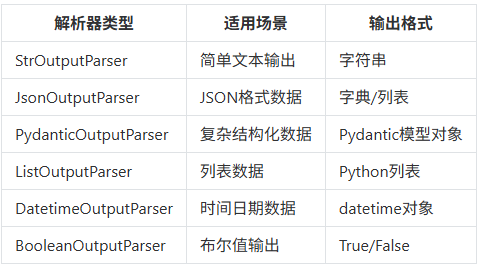


### 输出解析器方法
parse：将大模型输出的内容，格式化成指定的格式返回。

format_instructions：它会返回一段清晰的格式说明字符串，告诉 model 希望输出成什么格式（比如 JSON，或者特定格式）。

### 输出解析器类继承关系
分析LangChain源码可知，在 LangChain 的类结构中，顶层基类是 BaseLLMOutputParser，用于定义所有 LLM 输出解析器的抽象父类。而BaseTransformOutputParser是一个泛型类，用于“对模型输出进行转换”，我们常用的 StrOutputParser、ListOutputParser等均继承自 BaseTransformOutputParser。

## 常用输出解析器用法
### 字符串解析器
StrOutputParser是LangChain中最简单的输出解析器，它可以简单地将任何输入转换为字符串。从结果中提取content字段转换为字符串输出。

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 创建聊天提示模板，包含系统角色设定和用户问题输入
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个{role}，请简短回答我提出的问题"),
    ("human", "请回答:{question}")
])

# 使用指定的角色和问题生成具体的提示内容
prompt = chat_prompt.invoke({"role": "AI助手", "question": "什么是LangChain"})
logger.info(prompt)

# 初始化Deepseek聊天模型，使用deepseek-chat模型并关闭推理模式
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 调用模型获取回答结果
result = model.invoke(prompt)
logger.info(f"模型原始输出:\n{result}")

# 创建字符串输出解析器，用于解析模型返回的结果
parser = StrOutputParser ()

# 打印解析后的结构化结果
response = parser.invoke(result)
logger.info(f"解析后的结构化结果:\n{response}")

# 打印类型
logger.info(f"结果类型: {type(response)}")

INFO:root:messages=[SystemMessage(content='你是一个AI助手，请简短回答我提出的问题', additional_kwargs={}, response_metadata={}), HumanMessage(content='请回答:什么是LangChain', additional_kwargs={}, response_metadata={})]
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:模型原始输出:
content='LangChain是一个用于开发由大型语言模型驱动的应用程序的框架。它提供了一套工具和组件，帮助开发者更高效地构建基于LLM的应用，例如聊天机器人、问答系统和智能代理等。LangChain的核心功能包括模型集成、提示管理、链式调用、记忆存储和工具调用等，简化了与语言模型交互的复杂性。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 21, 'total_tokens': 94, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 21}, 'model_provider': 'deepseek', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_eaab8d114b_prod0820_fp8_kvcache_new_kvcache_20260410', 'id': '26fcb898-a9aa-49d0-9765-37950fa62500', 'finish_reason': 'stop', 'logprobs': None} id='

## Json 解析器
JsonOutputParser，即JSON输出解析器，是一种用于将大模型的自由文本输出转换为结构化JSON数据的工具。

适合场景：特别适用于需要严格结构化输出的场景，比如 API 调用、数据存储或下游任务处理。

实现方式：

- 用户自己通过提示词指明返回Json格式
- 借助JsonOutputParser的get_format_instructions() ，生成格式说明，指导模型输出JSON 结构

指定提示词指明返回 json 格式

In [7]:
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 创建聊天提示模板，包含系统角色设定和用户问题输入
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个{role}，请简短回答我提出的问题，结果返回json格式，q字段表示问题，a字段表示答案。"),
    ("human", "请回答:{question}")
])

# 使用指定的角色和问题生成具体的提示内容
prompt = chat_prompt.invoke({"role": "AI助手", "question": "什么是LangChain"})
logger.info(prompt)

# 初始化Deepseek聊天模型，使用deepseek-chat模型并关闭推理模式
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 调用模型获取回答结果
result = model.invoke(prompt)
logger.info(f"模型原始输出:\n{result}")
# 创建JSON输出解析器实例
parser = JsonOutputParser()
# 调用解析器处理结果数据，将输入转换为JSON格式的响应
response = parser.invoke(result)
logger.info(f"解析后的结构化结果:\n{response}")

# 打印类型
logger.info(f"结果类型: {type(response)}")


INFO:root:messages=[SystemMessage(content='你是一个AI助手，请简短回答我提出的问题，结果返回json格式，q字段表示问题，a字段表示答案。', additional_kwargs={}, response_metadata={}), HumanMessage(content='请回答:什么是LangChain', additional_kwargs={}, response_metadata={})]
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:模型原始输出:
content='{\n  "q": "什么是LangChain",\n  "a": "LangChain是一个开源框架，用于构建基于大型语言模型（LLM）的应用程序。它提供工具和组件，帮助开发者连接LLM与外部数据源、管理对话上下文，并简化复杂任务（如问答、摘要和代码生成）的开发流程。"\n}' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 37, 'total_tokens': 109, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 37}, 'model_provider': 'deepseek', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_eaab8d114b_prod0820_fp8_kvcache_new_kvcache_20260410', 'id': 'c57d10f9-bdfd-48c1-a7ef-ce8b150f136f', 'finish_reason': 'sto

使用get_format_instructions 生成格式说明。

In [8]:
from langchain_core.output_parsers import  JsonOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
from pydantic import BaseModel, Field
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

class Person(BaseModel):
    """
    定义一个新闻结构化的数据模型类

    属性:
        time (str): 新闻发生的时间
        person (str): 新闻涉及的人物
        event (str): 发生的具体事件
    """
    time: str = Field(description="时间")
    person: str = Field(description="人物")
    event: str = Field(description="事件")

# 创建JSON输出解析器，用于将model输出解析为Person对象
parser = JsonOutputParser(pydantic_object=Person)

# 获取格式化指令，告诉model如何输出符合要求的JSON格式
format_instructions = parser.get_format_instructions()

# 创建聊天提示模板，定义系统角色和用户输入格式
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你只能输出结构化JSON数据。"),
    ("human", "请生成一个关于{topic}的新闻。{format_instructions}")
])

# 格式化提示词，填入具体主题和格式化指令
prompt = chat_prompt.format_messages(topic="小米", format_instructions=format_instructions)

# 记录格式化后的提示词信息
logger.info(prompt)

# 初始化Deepseek聊天模型，使用deepseek-chat模型并关闭推理模式
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 调用大语言模型获取响应结果
result = model.invoke(prompt)

# 记录模型返回的结果
logger.info(f"模型原始输出:\n{result}")

# 使用解析器将模型输出解析为结构化数据
response = parser.invoke(result)
logger.info(f"解析后的结构化结果:\n{response}")

# 打印类型
logger.info(f"结果类型: {type(response)}")


INFO:root:[SystemMessage(content='你是一个AI助手，你只能输出结构化JSON数据。', additional_kwargs={}, response_metadata={}), HumanMessage(content='请生成一个关于小米的新闻。STRICT OUTPUT FORMAT:\n- Return only the JSON value that conforms to the schema. Do not include any additional text, explanations, headings, or separators.\n- Do not wrap the JSON in Markdown or code fences (no ``` or ```json).\n- Do not prepend or append any text (e.g., do not write "Here is the JSON:").\n- The response must be a single top-level JSON value exactly as required by the schema (object/array/etc.), with no trailing commas or comments.\n\nThe output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]} the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is no

### 列表解析器
利用CommaSeparatedListOutputParser解析器，可以将模型的文本响应转换为一个用逗号分隔的列表（List[str]）

In [ ]:
from langchain_core.output_parsers import CommaSeparatedListOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 创建逗号分隔列表输出解析器实例
parser = CommaSeparatedListOutputParser()

# 获取格式化指令，用于指导模型输出格式
format_instructions = parser.get_format_instructions()

# 创建聊天提示模板，包含系统消息和人类消息
# 系统消息定义了AI助手的行为规范和输出格式要求
# 人类消息定义了具体的任务请求，使用占位符{topic}表示主题
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", f"你是一个AI助手，你只能输出结构化列表数据。{format_instructions}"),
    ("human", "请生成5个关于{topic}的内容")
])

# 格式化聊天提示消息，将占位符替换为实际值
prompt = chat_prompt.format_messages(topic="小米", format_instructions=format_instructions)

# 记录格式化后的提示消息
logger.info(prompt)

# 初始化Deepseek聊天模型，使用deepseek-chat模型并关闭推理模式
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 调用模型执行推理，传入格式化的提示消息
result = model.invoke(prompt)

# 记录模型返回的原始结果
logger.info(f"模型原始输出:\n{result}")

# 使用解析器处理模型返回的结果，将其转换为结构化列表
response = parser.invoke(result)
logger.info(f"解析后的结构化结果:\n{response}")

# 打印类型
logger.info(f"结果类型: {type(response)}")

### XML 解析器
XMLOutputParser，将模型的自由文本输出转换为可编程处理的 XML 数据。

注意：XMLOutputParser 不会直接将模型的输出保持为原始XML字符串，而是会解析XML并转换成Python字典（或类似结构化的数据）。目的是为了方便程序后续处理数据，而不是单纯保留XML格式。

In [ ]:
from langchain_core.output_parsers import XMLOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 创建 XML 输出解析器实例
parser = XMLOutputParser()

# 获取格式化指令（这会告诉模型如何以 XML 格式输出）
format_instructions = parser.get_format_instructions()

# 创建提示模板
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", f"你是一个AI助手，只能输出XML格式的结构化数据。{format_instructions}"),
    ("human", "请生成5个关于{topic}的内容，每个内容包含<name>和<description>两个字段")
])

# 格式化提示，将 {topic} 替换为实际主题
prompt = chat_prompt.format_messages(topic="小米", format_instructions=format_instructions)

# 打印提示消息
logger.info(prompt)

# 初始化Deepseek聊天模型，使用deepseek-chat模型并关闭推理模式
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 执行推理
result = model.invoke(prompt)

# 记录模型原始输出
logger.info(f"模型原始输出:\n{result.content}")

# 解析 XML 输出为结构化 Python 对象（例如字典或列表）
response = parser.invoke(result)

# 打印解析后的结构化结果
logger.info(f"解析后的结构化结果:\n{response}")

# 打印类型
logger.info(f"结果类型: {type(response)}")


INFO:root:[SystemMessage(content='你是一个AI助手，只能输出XML格式的结构化数据。The output should be formatted as a XML file.\n1. Output should conform to the tags below.\n2. If tags are not given, make them on your own.\n3. Remember to always open and close all the tags.\n\nAs an example, for the tags ["foo", "bar", "baz"]:\n1. String "<foo>\n   <bar>\n      <baz></baz>\n   </bar>\n</foo>" is a well-formatted instance of the schema.\n2. String "<foo>\n   <bar>\n   </foo>" is a badly-formatted instance.\n3. String "<foo>\n   <tag>\n   </tag>\n</foo>" is a badly-formatted instance.\n\nHere are the output tags:\n```\nNone\n```', additional_kwargs={}, response_metadata={}), HumanMessage(content='请生成5个关于小米的内容，每个内容包含<name>和<description>两个字段', additional_kwargs={}, response_metadata={})]
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:模型原始输出:
<response>
  <content>
    <name>小米手机</name>
    <description>小米手机是小米公司推出的智能手机系列，以高性价比和创新技术著称，如小米数字系列和Redmi子品牌，覆盖从入门到

## 解析器进阶用法
### Pydantic解析器
PydanticOutputParser 是 LangChain 输出解析器体系中最常用、最强大的结构化解析器之一。
它与 JsonOutputParser 类似，但功能更强 —— 能直接基于 Pydantic 模型 定义输出结构，并利用其类型校验与自动文档能力。 对于结构更复杂、具有强类型约束的需求，PydanticOutputParser 则是最佳选择。它结合了Pydantic模型的强大功能，提供了类型验证、数据转换等高级功能，使用示例如下：

In [ ]:
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

from pydantic import BaseModel, Field, field_validator

class Product(BaseModel):
    """
    产品信息模型类，用于定义产品的结构化数据格式

    属性:
        name (str): 产品名称
        category (str): 产品类别
        description (str): 产品简介，长度必须大于等于10个字符
    """
    name: str = Field(description="产品名称")
    category: str = Field(description="产品类别")
    description: str = Field(description="产品简介")

    @field_validator("description")
    def validate_description(cls, value):
        """
        验证产品简介字段的长度

        参数:
            value (str): 待验证的产品简介文本

        返回:
            str: 验证通过的产品简介文本

        异常:
            ValueError: 当产品简介长度小于10个字符时抛出
        """
        if len(value) < 10:
            raise ValueError('产品简介长度必须大于等于10')
        return value

# 创建Pydantic输出解析器实例，用于解析模型输出为Product对象
parser = PydanticOutputParser(pydantic_object=Product)

# 获取格式化指令，用于指导模型输出符合Product模型的JSON格式
format_instructions = parser.get_format_instructions()

# 创建聊天提示模板，包含系统消息和人类消息
prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你只能输出结构化的json数据\n{format_instructions}"),
    ("human", "请你输出标题为：{topic}的新闻内容")
])

# 格式化提示消息，填充主题和格式化指令
prompt = prompt_template.format_messages(topic="小米", format_instructions=format_instructions)

# 记录格式化后的提示消息
logger.info(prompt)

# 初始化Deepseek聊天模型，使用deepseek-chat模型并关闭推理模式
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 调用模型获取结果
result = model.invoke(prompt)

# 记录模型返回的结果
logger.info(f"模型原始输出:\n{result.content}")

# 使用解析器将模型结果解析为Product对象
response = parser.invoke(result)

# 打印解析后的结构化结果
logger.info(f"解析后的结构化结果:\n{response}")

# 打印类型
logger.info(f"结果类型: {type(response)}")
